‎ 


# 0. Setup

In [16]:
from Requirements import *

from collections import Counter
from sklearn.model_selection import train_test_split

In [2]:
from tensorflow.keras.datasets import mnist

2025-10-01 15:25:08.650738: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-01 15:25:08.807622: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-01 15:25:08.974482: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-01 15:25:09.095200: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-01 15:25:09.128833: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-01 15:25:09.369885: I tensorflow/core/platform/cpu_feature_gu

In [20]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


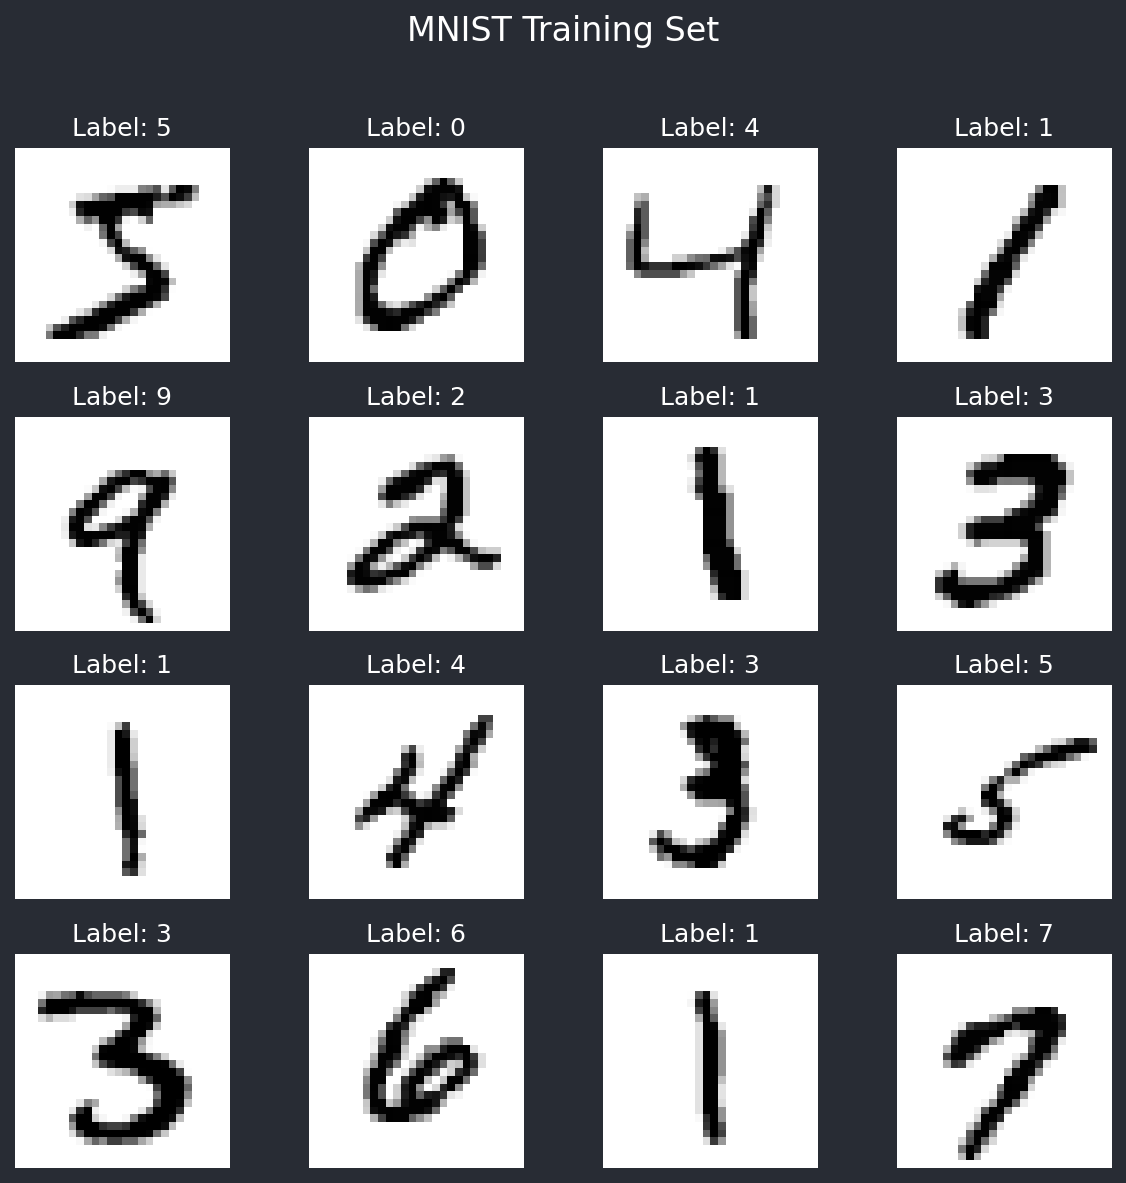

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(x_train[i], cmap='gray_r')
    
    ax.set_title(f"Label: {y_train[i]}")
    
    ax.axis('off')

plt.suptitle("MNIST Training Set", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [36]:
number_samples = 500

x_train_new, _, y_train_new, _ = train_test_split(x_train, y_train, train_size = number_samples, random_state = 42, stratify = y_train)

x_test_new, _, y_test_new, _ = train_test_split(x_test, y_test, train_size = int(number_samples/10), random_state = 42, stratify = y_test)

train_counts = Counter(y_train_new)
test_counts = Counter(y_test_new)

headers = sorted(train_counts.keys())
train_row = ["Train",] + [train_counts[d] for d in headers]
test_row = ["Test",] + [test_counts[d] for d in headers]
train_percentage_row = ["Train %",] + [f"{(train_counts[d]/number_samples)*100:.1f}%" for d in headers]
test_percentage_row = ["Test %",] + [f"{(test_counts[d]/(number_samples/10))*100:.1f}%" for d in headers]

print(f"\nDistribution of digits in the training set (n={number_samples}):\n")
print(tabulate([train_row, train_percentage_row], headers=["Set"] + headers))

print("\n" + "-"*50 + "\n")

print(f"\nDistribution of digits in the test set (n={int(number_samples/10)}):\n")
print(tabulate([test_row, test_percentage_row], headers=["Set"] + headers))



Distribution of digits in the training set (n=500):

Set      0     1      2      3      4     5     6     7      8     9
-------  ----  -----  -----  -----  ----  ----  ----  -----  ----  -----
Train    49    56     50     51     49    45    49    52     49    50
Train %  9.8%  11.2%  10.0%  10.2%  9.8%  9.0%  9.8%  10.4%  9.8%  10.0%

--------------------------------------------------


Distribution of digits in the test set (n=50):

Set     0      1      2      3      4      5     6      7      8      9
------  -----  -----  -----  -----  -----  ----  -----  -----  -----  -----
Test    5      6      5      5      5      4     5      5      5      5
Test %  10.0%  12.0%  10.0%  10.0%  10.0%  8.0%  10.0%  10.0%  10.0%  10.0%


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [38]:

x_train_flat = x_train_new.reshape(x_train_new.shape[0], -1)
x_test_flat = x_test_new.reshape(x_test_new.shape[0], -1)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

In [42]:
pca_components = 16

pca = PCA(n_components = pca_components)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Shape of PCA-transformed x_train:", x_train_pca.shape)
print("Shape of PCA-transformed x_test:", x_test_pca.shape)

Shape of PCA-transformed x_train: (500, 16)
Shape of PCA-transformed x_test: (50, 16)


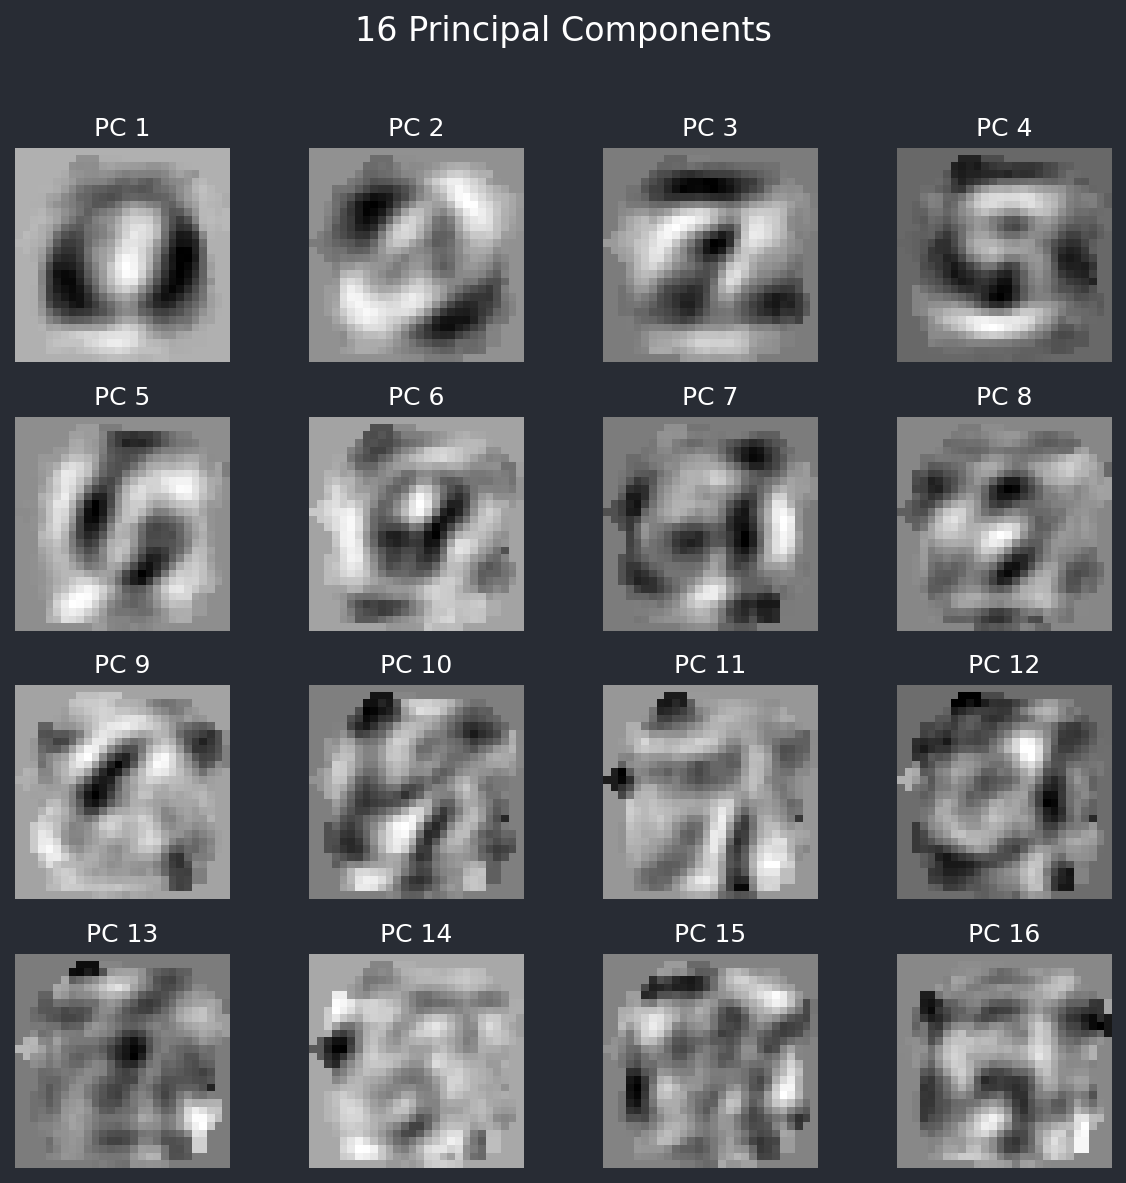

In [44]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(pca.components_[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')
    
plt.suptitle(f"{pca_components} Principal Components", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

‎ 

# 1. Quantum Loop

In [46]:
def get_quantum_distance(vec_alpha, vec_vj, shots=1024):

    num_qubits_per_state = int(np.log2(len(vec_alpha)))
    
    qc = QuantumCircuit(1 + 2 * num_qubits_per_state, 1)

    alpha_qubits = list(range(1, num_qubits_per_state + 1))
    vj_qubits = list(range(num_qubits_per_state + 1, 1 + 2 * num_qubits_per_state))
    
    qc.initialize(vec_alpha, alpha_qubits)
    qc.initialize(vec_vj, vj_qubits)
    
    ancilla_qubit = 0
    qc.h(ancilla_qubit)
    for i in range(num_qubits_per_state):
        qc.cswap(ancilla_qubit, alpha_qubits[i], vj_qubits[i])
    qc.h(ancilla_qubit)
    
    qc.measure(ancilla_qubit, 0)
    
    simulator = AerSimulator()
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    
    distance = counts.get('1', 0) / shots
    return distance


In [52]:
from operator import index


results_list = []
simulator = AerSimulator()

for i in tqdm(range(x_test_pca.shape[0])):
    
    test_vector = x_test_pca[i]
    test_label = y_test_new[i]
    
    norm_test_vector = np.linalg.norm(test_vector)
    
    if norm_test_vector == 0: continue
    
    normed_test_vector = test_vector / norm_test_vector
    
    for j in range(x_train_pca.shape[0]):
        
        train_vector = x_train_pca[j]
        train_label = y_train_new[j]
        
        norm_train_vector = np.linalg.norm(train_vector)
        
        if norm_train_vector == 0: continue
        
        normed_train_vector = train_vector / norm_train_vector
        
        distance = get_quantum_distance(normed_test_vector, normed_train_vector)

        results_list.append({'test_index': i, 'test_label': test_label, 'train_index': j, 'train_label': train_label, 'distance': distance})


  0%|          | 0/50 [00:00<?, ?it/s]

In [53]:
results_df = pd.DataFrame(results_list)

display(results_df)

print(f"\nDataFrame shape: {results_df.shape}")

,test_index,test_label,train_index,train_label,distance
0,0,7,0,4,0.491211
1,0,7,1,9,0.483398
2,0,7,2,7,0.040039
3,0,7,3,0,0.445312
4,0,7,4,4,0.503906
...,...,...,...,...,...
24995,49,3,495,1,0.524414
24996,49,3,496,2,0.494141
24997,49,3,497,1,0.524414
24998,49,3,498,3,0.428711



DataFrame shape: (25000, 5)


In [54]:
from scipy import stats
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [57]:
k = 5

predictions = []

test_indices = results_df['test_index'].unique()

for i in test_indices:
    
    neighbors = results_df[results_df['test_index'] == i]
    
    k_nearest_neighbors = neighbors.sort_values(by='distance').head(k)

    predicted_label = stats.mode(k_nearest_neighbors['train_label'], keepdims=False).mode
    
    true_label = k_nearest_neighbors['test_label'].iloc[0]

    predictions.append({'Test Image Index': i, 'True Label': true_label, 'Predicted Label': predicted_label, 'Correct': predicted_label == true_label})
    
df_predictions = pd.DataFrame(predictions)


In [61]:
display(df_predictions.head(10))

accuracy_score = accuracy_score(df_predictions['True Label'], df_predictions['Predicted Label'])

print(f"\nAccuracy: {accuracy_score*100:.2f}%")

,Test Image Index,True Label,Predicted Label,Correct
0,0,7,7,True
1,1,1,1,True
2,2,6,6,True
3,3,1,1,True
4,4,9,9,True
5,5,3,3,True
6,6,1,1,True
7,7,9,9,True
8,8,6,6,True
9,9,8,8,True



Accuracy: 80.00%


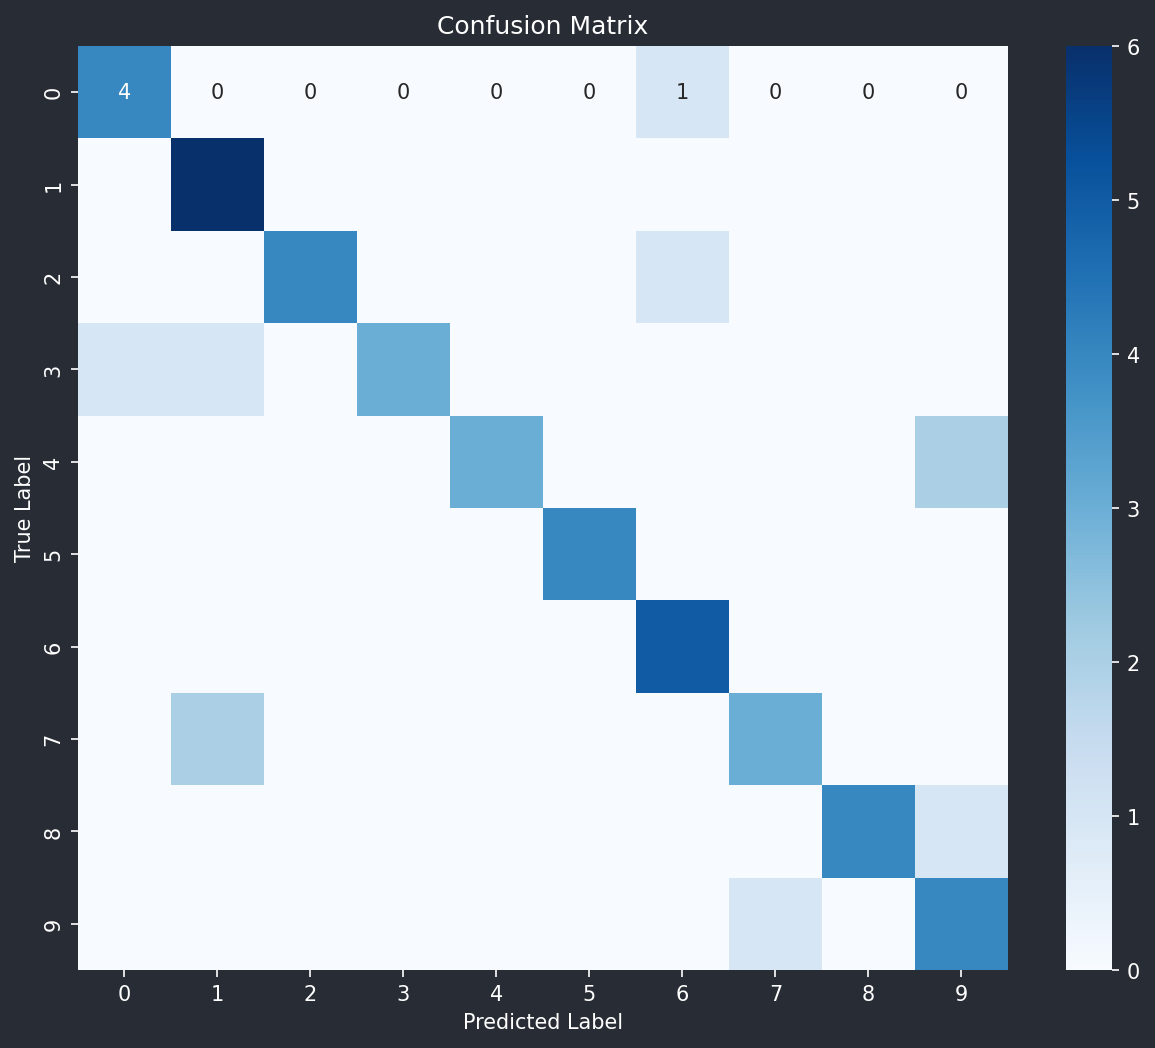

In [62]:

conf_matrix = confusion_matrix(df_predictions['True Label'], df_predictions['Predicted Label'])

plt.figure(figsize=(10, 8))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()